In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/maheshjd/data-viz-class-material/data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happy_Score','GDP','Social_Suppor','Life_Expectancy','Freedom','Generosity','Corruption']

print(f"Dataset: {len(df)}countries, {len(df.columns)} columns ")
print(df.head())

Dataset: 63countries, 9 columns 
       Country                        Region  Happy_Score     GDP  \
0      Finland                Western Europe        7.804  10.775   
1      Denmark                Western Europe        7.586  10.933   
2      Iceland                Western Europe        7.525  10.878   
3       Israel  Middle East and North Africa        7.473  10.527   
4  Netherlands                Western Europe        7.464  11.015   

   Social_Suppor  Life_Expectancy  Freedom  Generosity  Corruption  
0          0.954             71.9    0.949       0.142       0.179  
1          0.954             72.7    0.931       0.168       0.234  
2          0.983             72.5    0.961       0.260       0.150  
3          0.916             72.4    0.903       0.149       0.826  
4          0.939             72.4    0.879       0.240       0.296  


In [3]:
import plotly.express as px
import plotly.graph_objects as go

print('Regions in Dataset:')
print(df['Region'].value_counts())
print("\n Score_Range:", df['Happy_Score'].min(),"-",df['Happy_Score'].max())
print("\n Bottom 10 countries")
print(df.nsmallest(10, 'Happy_Score')[['Country','Region','Happy_Score']])

Regions in Dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

 Score_Range: 1.859 - 7.804

 Bottom 10 countries
        Country                        Region  Happy_Score
60  Afghanistan                    South Asia        1.859
61      Lebanon  Middle East and North Africa        2.392
62     Zimbabwe            Sub-Saharan Africa        2.995
52     Ethiopia            Sub-Saharan Africa        3.564
53     Tanzania            Sub-Saharan Africa        3.698
48   Bangladesh                    South Asia        3.892
47        India                    South Asia        4.036
50        Kenya            Sub-Saharan Africa        4.112
54       Uganda            Sub-Saharan Africa     

In [5]:
region_avg = (df.groupby('Region')['Happy_Score']
              .mean()
              .reset_index()
              .sort_values('Happy_Score')) 

print(region_avg)

                         Region  Happy_Score
5                    South Asia     3.618250
7            Sub-Saharan Africa     4.064714
3  Middle East and North Africa     4.943333
6                Southeast Asia     5.695250
2   Latin America and Caribbean     5.699000
1                     East Asia     5.966000
0    Central and Eastern Europe     6.338143
4         North America and ANZ     7.018250
8                Western Europe     7.085533


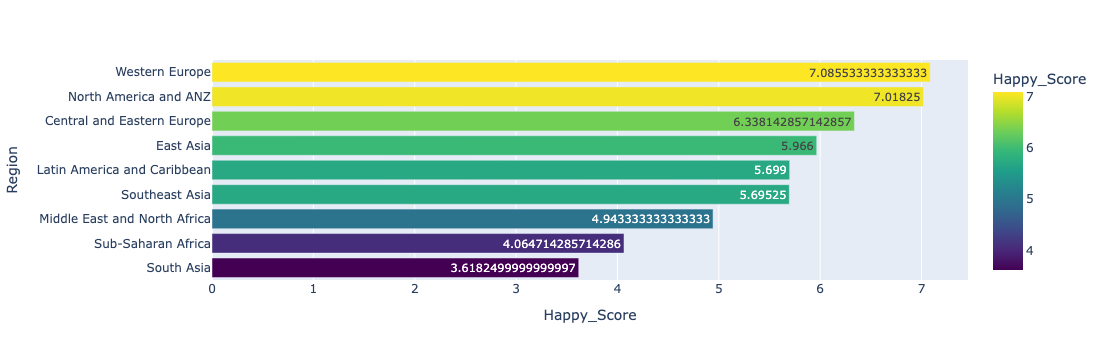

In [8]:
import plotly.express as px

fig = px.bar(region_avg, x ='Happy_Score', y = 'Region', orientation = 'h', 
             text = 'Happy_Score', color = 'Happy_Score',color_continuous_scale='Viridis')

fig.show()

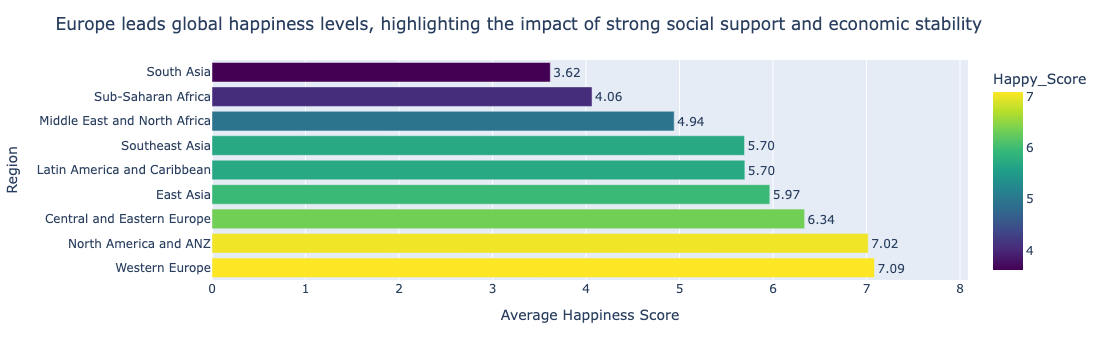

In [12]:
fig.update_layout(
    yaxis=dict(autorange="reversed"),
    
    # Insight title (important!)
    title="Europe leads global happiness levels, highlighting the impact of strong social support and economic stability",
    
    xaxis_title="Average Happiness Score",
    yaxis_title="Region"
)

fig.update_xaxes(range=[0, region_avg['Happy_Score'].max() + 1])

# Improve labels appearance
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

In [14]:
top8 = df.nlargest(8, 'Happy_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happy_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happy_Score')
global_avg = df['Happy_Score'].mean()
print(f"Global average: {global_avg:.2f}")

Global average: 5.81


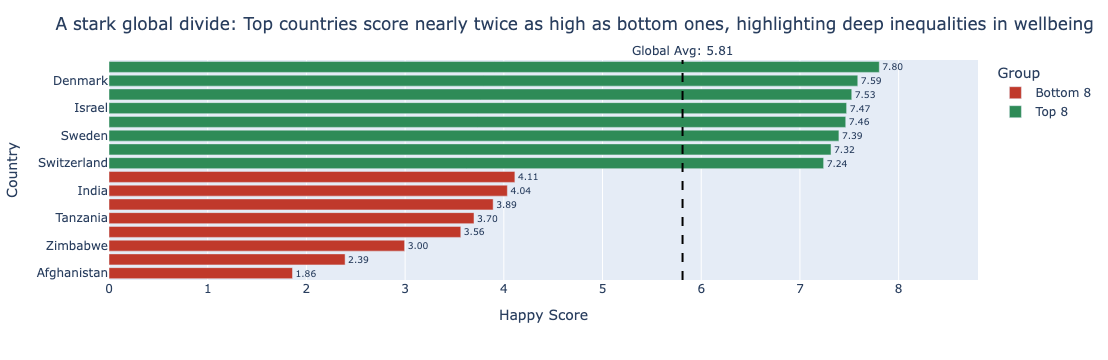

In [16]:
import plotly.express as px

# Ensure sorted (bottom → top for horizontal chart)
combined = combined.sort_values('Happy_Score')

# Custom colors (NOT default)
color_map = {
    'Top 8': '#2E8B57',     # green
    'Bottom 8': '#C0392B'   # red
}

fig = px.bar(
    combined,
    x='Happy_Score',
    y='Country',
    orientation='h',
    color='Group',
    color_discrete_map=color_map,
    text='Happy_Score'
)

# Add global average line (visual separator)
fig.add_vline(
    x=global_avg,
    line_dash="dash",
    line_color="black",
    annotation_text=f"Global Avg: {global_avg:.2f}",
    annotation_position="top"
)

# Improve labels
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

# Layout improvements + insight title
fig.update_layout(
    title="A stark global divide: Top countries score nearly twice as high as bottom ones, highlighting deep inequalities in wellbeing",
    xaxis_title="Happy Score",
    yaxis_title="Country",
    showlegend=True
)

# Ensure zero baseline
fig.update_xaxes(range=[0, combined['Happy_Score'].max() + 1])

fig.show()

In [17]:
regions = ['Western Europe', 'Latin America', 'East Asia', 
           'Sub-Saharan Africa', 'South Asia']   #filter the regions we want to consider

filtered = df[df['Region'].isin(regions)]

In [18]:
grouped = (
    filtered.groupby('Region')[['GDP', 'Freedom']]
    .mean()
    .reset_index()
)           #Aggregate region wise 

In [19]:
melted = grouped.melt(
    id_vars='Region',
    value_vars=['GDP', 'Freedom'],
    var_name='Factor',
    value_name='Score'
)    #reshape for grouped bars

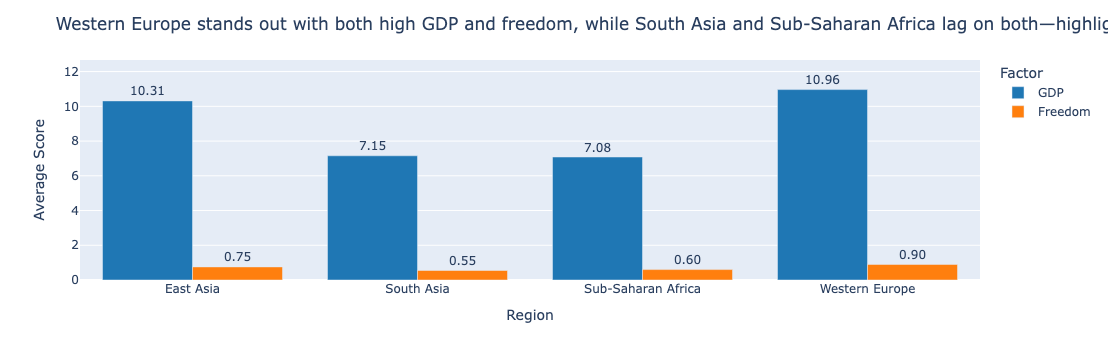

In [20]:
import plotly.express as px

color_map = {
    'GDP': '#1f77b4',       # blue → economic strength
    'Freedom': '#ff7f0e'    # orange → personal liberty
}

fig = px.bar(
    melted,
    x='Region',
    y='Score',
    color='Factor',
    barmode='group',
    color_discrete_map=color_map,
    text='Score'
)

# Improve labels
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

# Insight title + layout
fig.update_layout(
    title="Western Europe stands out with both high GDP and freedom, while South Asia and Sub-Saharan Africa lag on both—highlighting how economic and social factors jointly shape wellbeing",
    xaxis_title="Region",
    yaxis_title="Average Score",
    legend_title="Factor"
)

fig.show()